In [4]:
import csv
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [6]:
#Load data from CSV files
hist_data = pd.read_csv('C:\\Users\\KARAN\\Desktop\\College\\projects\\Company Trials\\Primetrade.ai\\Dataset\\historical_data.csv')
greedy_data = pd.read_csv('C:\\Users\\KARAN\\Desktop\\College\\projects\\Company Trials\\Primetrade.ai\\Dataset\\fear_greed_index.csv')

print(f'Historical data : {hist_data.shape[0]:,} rows × {hist_data.shape[1]} columns')
print(f'Fear/Greed data : {greedy_data.shape[0]:,} rows × {greedy_data.shape[1]} columns')

Historical data : 211,224 rows × 16 columns
Fear/Greed data : 2,644 rows × 4 columns


In [7]:
hist_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
greedy_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [11]:
#cleaning dataset
print("Checking for any null values in historical data:")
print(hist_data.isnull().sum())
print("="*100)

print("Checking for any null values in fear/greed data:")
print(greedy_data.isnull().sum())
print("="*100)

Checking for any null values in historical data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Checking for any null values in fear/greed data:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [13]:
#Changing date format to datetime
hist_data['date'] = pd.to_datetime(hist_data['Timestamp IST'], dayfirst=True).dt.normalize()
greedy_data['date']   = pd.to_datetime(greedy_data['date'])

In [14]:
#filtering the closing trades
CLOSE_DIRS = {'Close Long', 'Close Short'}
closed = hist_data[hist_data['Direction'].isin(CLOSE_DIRS)].copy()

In [15]:
# Creating a binary target variable 'win' where 1 indicates a profitable trade and 0 indicates a loss or break-even
closed['win'] = (closed['Closed PnL'] > 0).astype(int)

In [17]:
#printing all the statements
print(f'Total trades           : {len(hist_data):,}')
print(f'Closed (realized) trades: {len(closed):,}')
print(f'Direction breakdown:\n{hist_data["Direction"].value_counts()}')

Total trades           : 211,224
Closed (realized) trades: 84,691
Direction breakdown:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [20]:
#Sentiment colour palette & ordering
SENT_COLORS = {
    'Extreme Fear':  '#e74c3c',
    'Fear':          '#e67e22',
    'Neutral':       '#f1c40f',
    'Greed':         '#2ecc71',
    'Extreme Greed': '#1abc9c',
}
SENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

In [21]:
#merging both the datasets on data feature
merged = closed.merge(greedy_data[['date', 'value', 'classification']], on='date', how='inner')
merged['classification'] = pd.Categorical(
    merged['classification'], categories=SENT_ORDER, ordered=True)

print(f'Merged dataset          : {len(merged):,} trades')
print(f'Date range              : {merged["date"].min().date()} → {merged["date"].max().date()}')
print(f'Unique traders          : {merged["Account"].nunique()}')
print(f'Unique coins            : {merged["Coin"].nunique()}')
merged.head()

Merged dataset          : 84,685 trades
Date range              : 2023-12-14 → 2025-05-01
Unique traders          : 32
Unique coins            : 168


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.49,14.78,3584.00,SELL,03-12-2024 20:56,1000.00,Close Long,139.418262,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,1.254400,2.380000e+14,1.730000e+12,2024-12-03,1,76,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.47,8.65,2097.37,SELL,03-12-2024 20:56,985.22,Close Long,81.421585,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.734077,4.160000e+14,1.730000e+12,2024-12-03,1,76,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.46,13.67,3314.43,SELL,03-12-2024 20:56,976.57,Close Long,128.537643,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,1.160049,1.120000e+15,1.730000e+12,2024-12-03,1,76,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.45,0.06,14.55,SELL,03-12-2024 20:56,962.90,Close Long,0.563574,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.005091,5.980000e+13,1.730000e+12,2024-12-03,1,76,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,242.36,3.68,891.88,SELL,03-12-2024 20:56,962.84,Close Long,34.234672,0x94e25a0cc04d89b3ad530418544d29020118004cffc9...,52305625381,True,0.312159,6.480000e+14,1.730000e+12,2024-12-03,1,76,Extreme Greed


EDA Processes

In [22]:
print('=== Closed PnL Summary Statistics ===')
print(merged['Closed PnL'].describe())
print(f'\nTotal realized PnL (all traders): ${merged["Closed PnL"].sum():,.2f}')
print(f'Overall win rate                : {merged["win"].mean()*100:.2f}%')

=== Closed PnL Summary Statistics ===
count     84685.000000
mean         86.086763
std        1308.125941
min     -117990.104100
25%           0.428694
50%           5.880000
75%          36.951432
max      135329.090100
Name: Closed PnL, dtype: float64

Total realized PnL (all traders): $7,290,257.50
Overall win rate                : 83.54%


In [23]:
print('=== Top 10 Most Traded Coins ===')
print(merged['Coin'].value_counts().head(10))

print('\n=== Sentiment Distribution in Trade Data ===')
print(merged['classification'].value_counts())

=== Top 10 Most Traded Coins ===
Coin
HYPE        31985
BTC         11026
ETH          5205
SOL          5016
MELANIA      2209
FARTCOIN     2162
kBONK        1164
kPEPE        1035
TRUMP         958
WLD           940
Name: count, dtype: int64

=== Sentiment Distribution in Trade Data ===
classification
Fear             26481
Greed            19320
Neutral          15843
Extreme Greed    13683
Extreme Fear      9358
Name: count, dtype: int64


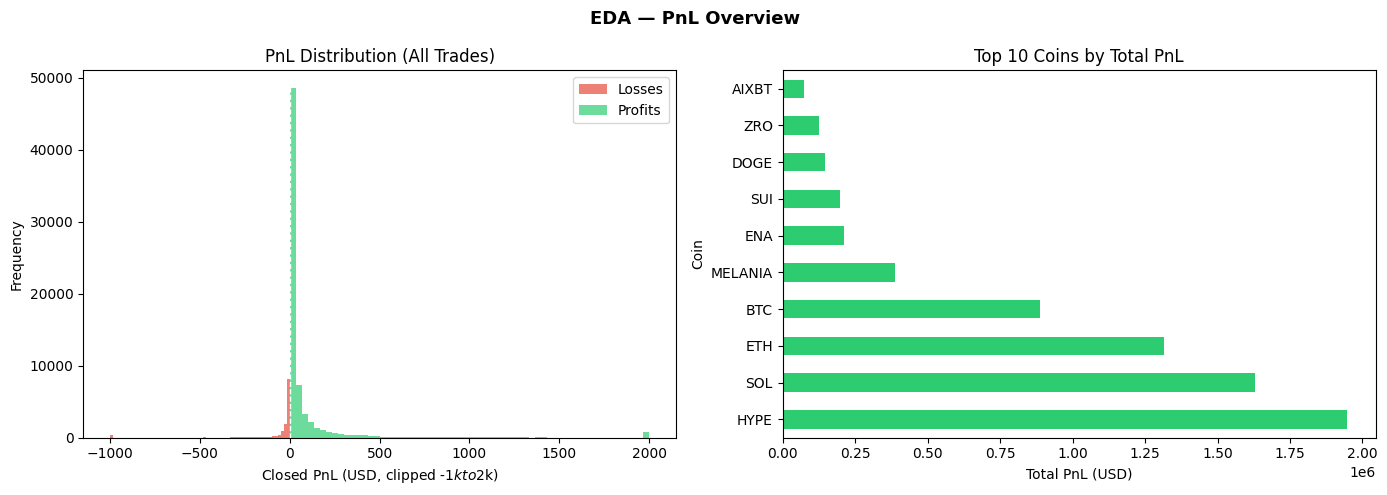

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — PnL Overview', fontsize=13, fontweight='bold')

# Histogram of PnL (clipped for readability)
ax = axes[0]
clipped = merged['Closed PnL'].clip(-1000, 2000)
ax.hist(clipped[clipped < 0],  bins=60, color='#e74c3c', alpha=0.7, label='Losses')
ax.hist(clipped[clipped >= 0], bins=60, color='#2ecc71', alpha=0.7, label='Profits')
ax.axvline(0, color='white', linewidth=1, linestyle='--')
ax.set_xlabel('Closed PnL (USD, clipped -$1k to $2k)')
ax.set_ylabel('Frequency')
ax.set_title('PnL Distribution (All Trades)')
ax.legend()

# Top 10 coins by total PnL
ax = axes[1]
top_pnl = merged.groupby('Coin')['Closed PnL'].sum().nlargest(10)
colors_bar = ['#2ecc71' if v >= 0 else '#e74c3c' for v in top_pnl.values]
top_pnl.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='none')
ax.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Total PnL (USD)')
ax.set_title('Top 10 Coins by Total PnL')

plt.tight_layout()
plt.show()

Performance Overview

In [25]:
# ── Aggregate by sentiment ───────────────────────────────────────────────────
sent_stats = (
    merged.groupby('classification', observed=True)
    .agg(
        total_trades  = ('Closed PnL', 'count'),
        total_pnl     = ('Closed PnL', 'sum'),
        avg_pnl       = ('Closed PnL', 'mean'),
        median_pnl    = ('Closed PnL', 'median'),
        win_rate      = ('win', 'mean'),
        avg_size_usd  = ('Size USD', 'mean'),
        total_fee     = ('Fee', 'sum'),
    )
    .reset_index()
)
sent_stats['win_rate_pct'] = (sent_stats['win_rate'] * 100).round(2)
sent_stats['avg_pnl']      = sent_stats['avg_pnl'].round(2)
sent_stats['total_pnl']    = sent_stats['total_pnl'].round(2)
sent_stats

,classification,total_trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_size_usd,total_fee,win_rate_pct
0,Extreme Fear,9358,891391.33,95.25,8.051683,0.799637,5880.463817,11831.067432,79.96
1,Fear,26481,3347568.38,126.41,7.109424,0.885918,8857.667254,45651.573306,88.59
2,Neutral,15843,1082346.59,68.32,4.400000,0.830020,6110.902113,21129.386095,83.00
3,Greed,19320,1336413.92,69.17,3.975331,0.760766,6614.316019,28310.247910,76.08
4,Extreme Greed,13683,632537.27,46.23,7.131500,0.873858,3488.460061,11884.131008,87.39


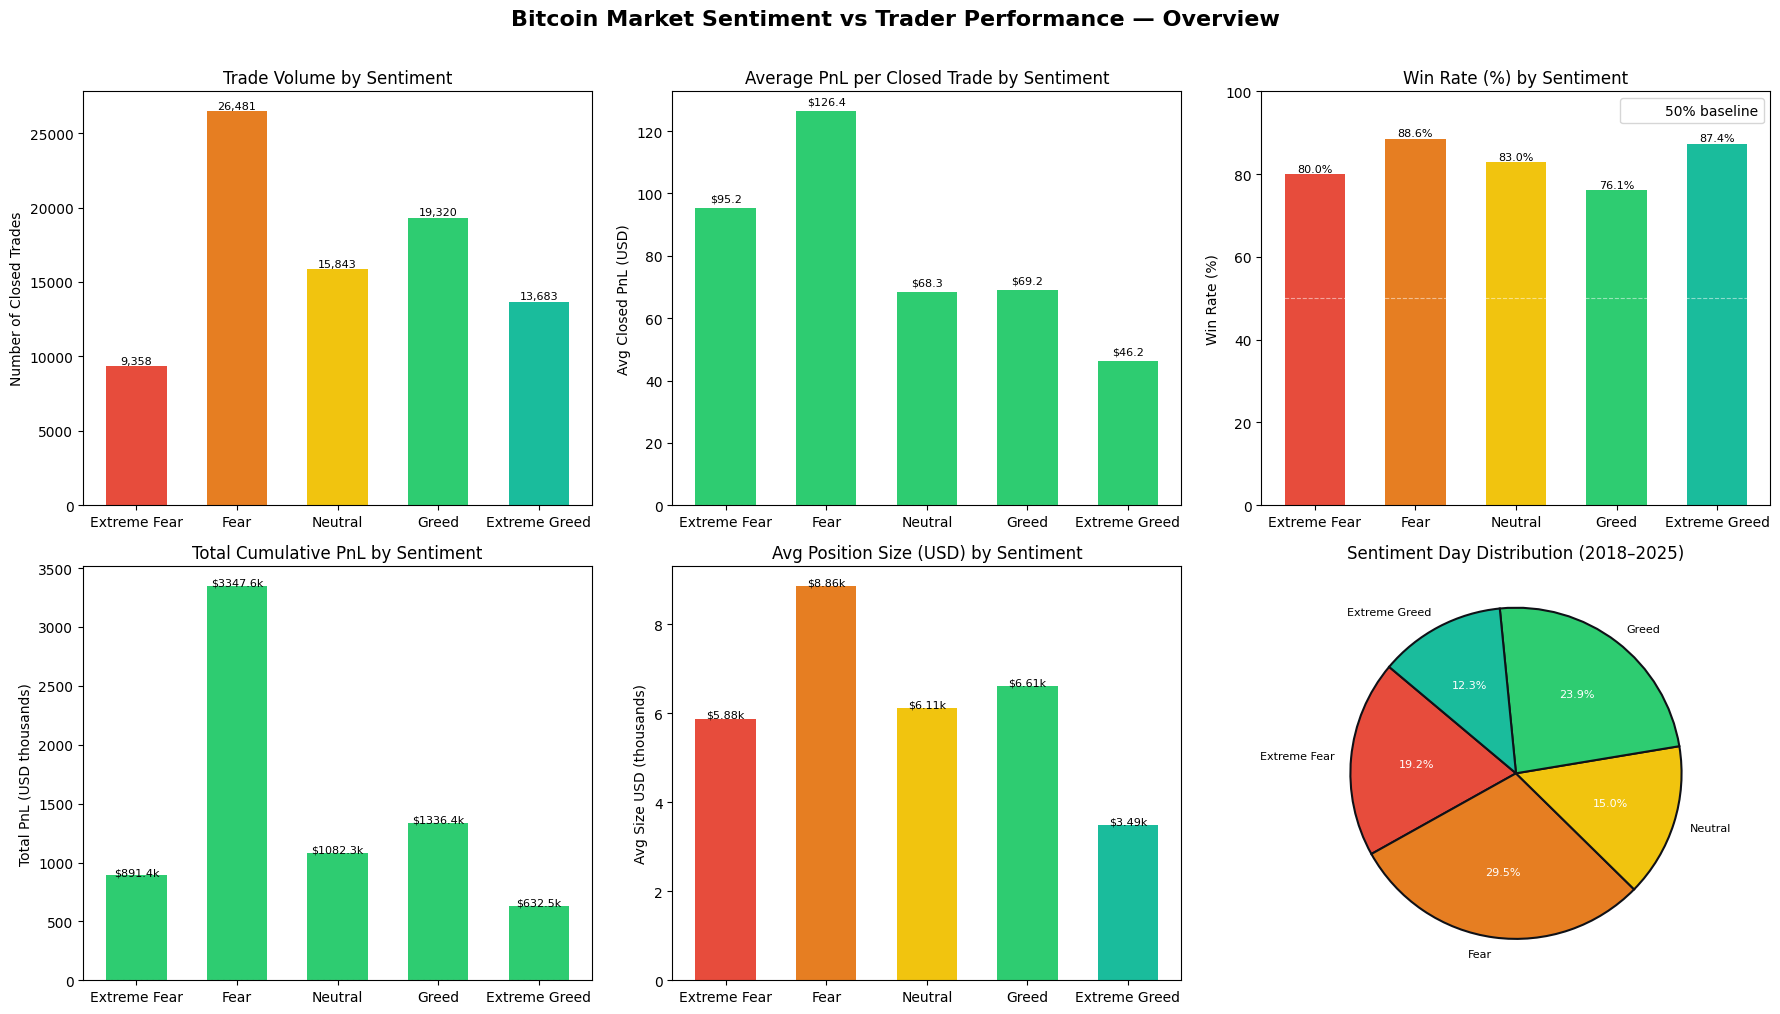

In [27]:
colors = [SENT_COLORS[s] for s in SENT_ORDER]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bitcoin Market Sentiment vs Trader Performance — Overview',
             fontsize=16, fontweight='bold', y=1.01)

# 1a: Trade count
ax = axes[0, 0]
bars = ax.bar(sent_stats['classification'], sent_stats['total_trades'],
              color=colors, edgecolor='none', width=0.6)
ax.set_title('Trade Volume by Sentiment')
ax.set_ylabel('Number of Closed Trades')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+30,
            f"{int(b.get_height()):,}", ha='center', va='bottom', fontsize=8)

# 1b: Average PnL
ax = axes[0, 1]
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in sent_stats['avg_pnl']]
bars = ax.bar(sent_stats['classification'], sent_stats['avg_pnl'],
              color=bar_colors, edgecolor='none', width=0.6)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Average PnL per Closed Trade by Sentiment')
ax.set_ylabel('Avg Closed PnL (USD)')
for b in bars:
    ypos = b.get_height() + (2 if b.get_height() >= 0 else -12)
    ax.text(b.get_x()+b.get_width()/2, ypos,
            f'${b.get_height():.1f}', ha='center', fontsize=8)

# 1c: Win rate
ax = axes[0, 2]
bars = ax.bar(sent_stats['classification'], sent_stats['win_rate_pct'],
              color=colors, edgecolor='none', width=0.6)
ax.axhline(50, color='white', linewidth=0.8, linestyle='--', alpha=0.5, label='50% baseline')
ax.set_title('Win Rate (%) by Sentiment')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 100)
ax.legend()
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{b.get_height():.1f}%', ha='center', fontsize=8)

# 1d: Total PnL
ax = axes[1, 0]
bar_colors2 = ['#e74c3c' if v < 0 else '#2ecc71' for v in sent_stats['total_pnl']]
bars = ax.bar(sent_stats['classification'], sent_stats['total_pnl']/1e3,
              color=bar_colors2, edgecolor='none', width=0.6)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Total Cumulative PnL by Sentiment')
ax.set_ylabel('Total PnL (USD thousands)')
for b in bars:
    ypos = b.get_height() + (0.5 if b.get_height() >= 0 else -2)
    ax.text(b.get_x()+b.get_width()/2, ypos,
            f'${b.get_height():.1f}k', ha='center', fontsize=8)

# 1e: Avg position size
ax = axes[1, 1]
bars = ax.bar(sent_stats['classification'], sent_stats['avg_size_usd']/1e3,
              color=colors, edgecolor='none', width=0.6)
ax.set_title('Avg Position Size (USD) by Sentiment')
ax.set_ylabel('Avg Size USD (thousands)')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
            f'${b.get_height():.2f}k', ha='center', fontsize=8)

# 1f: Sentiment day distribution (pie)
ax = axes[1, 2]
counts = greedy_data['classification'].value_counts().reindex(SENT_ORDER).fillna(0)
wedges, texts, autotexts = ax.pie(
    counts, labels=SENT_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 8},
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(8)
ax.set_title('Sentiment Day Distribution (2018–2025)')

plt.tight_layout()
plt.show()

Time Series Analysis

In [28]:
# Daily aggregates
daily = (
    merged.groupby(['date', 'classification', 'value'], observed=True)
    .agg(daily_pnl=('Closed PnL', 'sum'),
         trades=('Closed PnL', 'count'),
         win_rate=('win', 'mean'))
    .reset_index()
    .sort_values('date')
)
print(f'Daily aggregates: {len(daily)} trading days')
daily.head()

Daily aggregates: 409 trading days


,date,classification,value,daily_pnl,trades,win_rate
0,2023-12-14,Greed,72,-205.434737,6,0.666667
1,2023-12-15,Greed,70,-24.632034,2,0.000000
2,2023-12-17,Greed,73,304.982785,11,0.636364
3,2023-12-19,Greed,73,1000.538612,10,1.000000
4,2023-12-20,Greed,74,162.732282,8,1.000000


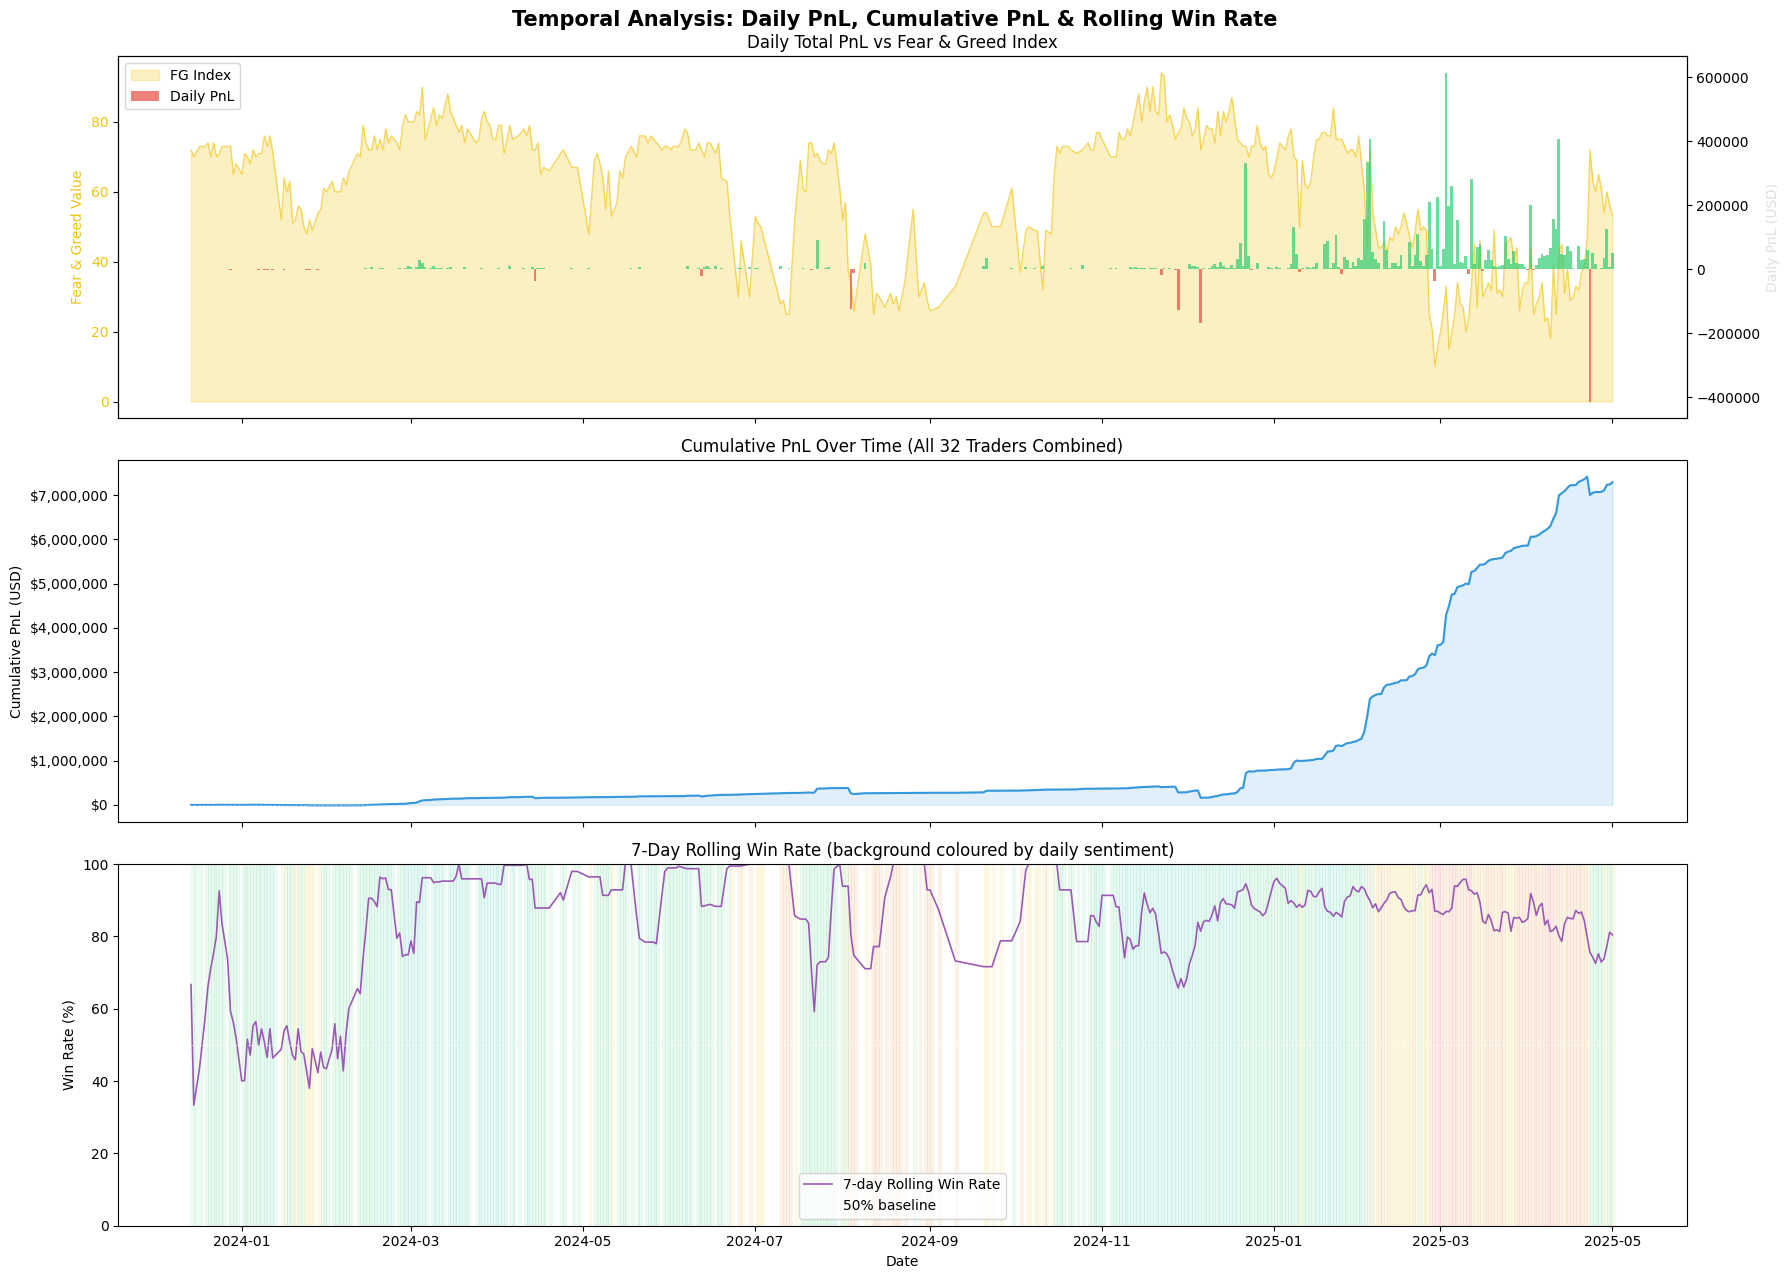

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(18, 13), sharex=True)
fig.suptitle('Temporal Analysis: Daily PnL, Cumulative PnL & Rolling Win Rate',
             fontsize=15, fontweight='bold')

# 2a: FG Index + Daily PnL
ax = axes[0]
ax2 = ax.twinx()
ax.fill_between(daily['date'], daily['value'], alpha=0.25, color='#f1c40f', label='FG Index')
ax.plot(daily['date'], daily['value'], color='#f1c40f', linewidth=0.8, alpha=0.6)
ax.set_ylabel('Fear & Greed Value', color='#f1c40f')
ax.tick_params(axis='y', labelcolor='#f1c40f')
ax2.bar(daily['date'],
        daily['daily_pnl'],
        color=daily['daily_pnl'].apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c'),
        width=1, alpha=0.7, label='Daily PnL')
ax2.set_ylabel('Daily PnL (USD)', color='#e0e0e0')
ax.set_title('Daily Total PnL vs Fear & Greed Index')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 2b: Cumulative PnL
ax = axes[1]
cum_pnl = daily.set_index('date')['daily_pnl'].cumsum()
ax.plot(cum_pnl.index, cum_pnl.values, color='#3498db', linewidth=1.5)
ax.fill_between(cum_pnl.index, cum_pnl.values, alpha=0.15, color='#3498db')
ax.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
ax.set_ylabel('Cumulative PnL (USD)')
ax.set_title('Cumulative PnL Over Time (All 32 Traders Combined)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# 2c: Rolling win rate with sentiment background
ax = axes[2]
daily_wr = daily.set_index('date')['win_rate'].rolling(7, min_periods=1).mean() * 100
ax.plot(daily_wr.index, daily_wr.values, color='#9b59b6', linewidth=1.2,
        label='7-day Rolling Win Rate')
ax.axhline(50, color='white', linewidth=0.8, linestyle='--', alpha=0.5, label='50% baseline')
for _, row in daily.iterrows():
    ax.axvspan(row['date'], row['date'] + pd.Timedelta(days=1),
               alpha=0.07, color=SENT_COLORS.get(str(row['classification']), '#888'))
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 100)
ax.set_xlabel('Date')
ax.set_title('7-Day Rolling Win Rate (background coloured by daily sentiment)')
ax.legend()

plt.tight_layout()
plt.show()

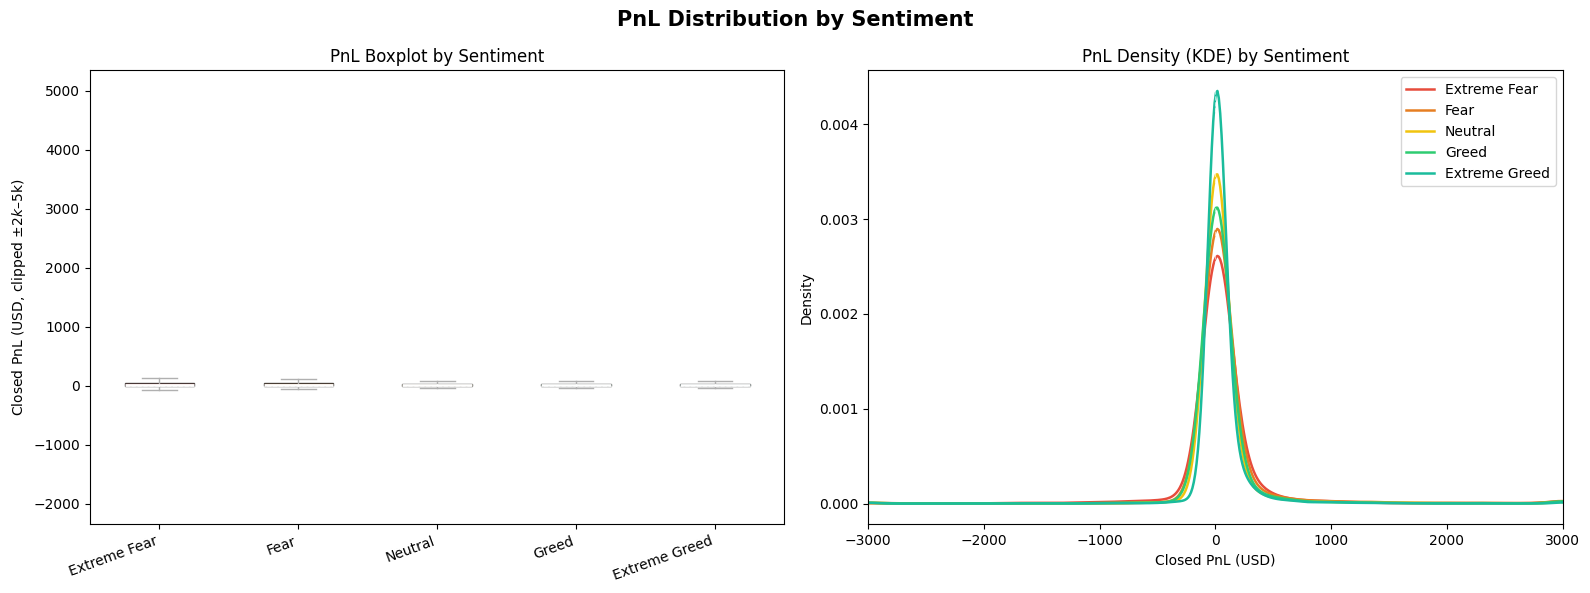

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PnL Distribution by Sentiment', fontsize=15, fontweight='bold')

# 3a: Boxplot
ax = axes[0]
data_by_sent = [
    merged[merged['classification'] == s]['Closed PnL'].clip(-2000, 5000)
    for s in SENT_ORDER
]
bp = ax.boxplot(data_by_sent, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#b0b0b0'),
                capprops=dict(color='#b0b0b0'),
                flierprops=dict(marker='o', markersize=2, alpha=0.3, markeredgewidth=0))
for patch, color in zip(bp['boxes'], [SENT_COLORS[s] for s in SENT_ORDER]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticklabels(SENT_ORDER, rotation=20, ha='right')
ax.set_ylabel('Closed PnL (USD, clipped ±$2k–$5k)')
ax.set_title('PnL Boxplot by Sentiment')

# 3b: KDE
ax = axes[1]
for s, color in SENT_COLORS.items():
    subset = merged[merged['classification'] == s]['Closed PnL'].clip(-3000, 3000)
    if len(subset) > 10:
        subset.plot.kde(ax=ax, color=color, label=s, linewidth=1.8, bw_method=0.3)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlim(-3000, 3000)
ax.set_xlabel('Closed PnL (USD)')
ax.set_ylabel('Density')
ax.set_title('PnL Density (KDE) by Sentiment')
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
trader_sent = (
    merged.groupby(['Account', 'classification'], observed=True)
    .agg(pnl=('Closed PnL', 'sum'),
         trades=('Closed PnL', 'count'),
         wr=('win', 'mean'))
    .reset_index()
)

# Anonymise wallet addresses → T1, T2, …
trader_map = {addr: f'T{i+1}' for i, addr in enumerate(trader_sent['Account'].unique())}
trader_sent['Trader'] = trader_sent['Account'].map(trader_map)

print(f'{trader_sent["Trader"].nunique()} unique traders')
trader_sent.head()

32 unique traders


,Account,classification,pnl,trades,wr,Trader
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,1.247692e+05,37,1.000000,T1
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1.112204e+06,1050,0.890476,T1
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,1.256501e+05,245,1.000000,T1
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,2.767193e+05,153,0.601307,T1
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,-4.028234e+04,246,0.256098,T1


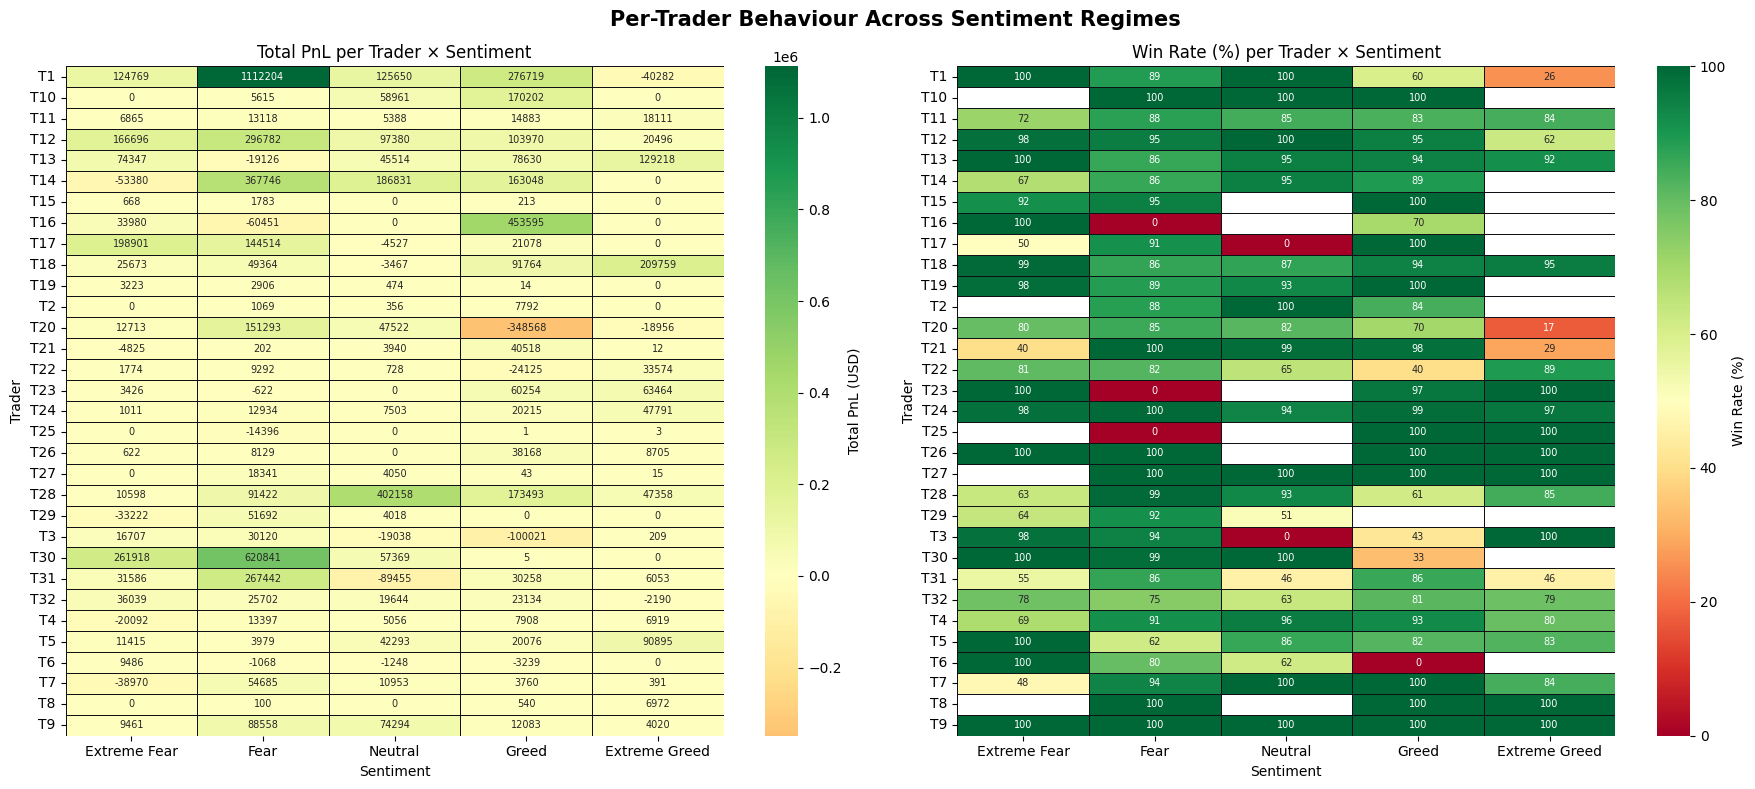

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Per-Trader Behaviour Across Sentiment Regimes', fontsize=15, fontweight='bold')

pivot_pnl = trader_sent.pivot(index='Trader', columns='classification', values='pnl').fillna(0)
pivot_wr  = trader_sent.pivot(index='Trader', columns='classification', values='wr').fillna(np.nan)

# 4a: PnL heatmap
ax = axes[0]
sns.heatmap(pivot_pnl[SENT_ORDER], ax=ax, cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='#0f1117',
            fmt='.0f', annot=True, annot_kws={'size': 7},
            cbar_kws={'label': 'Total PnL (USD)'})
ax.set_title('Total PnL per Trader × Sentiment')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Trader')

# 4b: Win rate heatmap
ax = axes[1]
sns.heatmap(pivot_wr[SENT_ORDER]*100, ax=ax, cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, linecolor='#0f1117',
            fmt='.0f', annot=True, annot_kws={'size': 7},
            cbar_kws={'label': 'Win Rate (%)'})
ax.set_title('Win Rate (%) per Trader × Sentiment')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Trader')

plt.tight_layout()
plt.show()

In [33]:
ls = (
    merged.groupby(['classification', 'Direction'], observed=True)
    .agg(count=('Closed PnL', 'count'),
         avg_pnl=('Closed PnL', 'mean'),
         wr=('win', 'mean'))
    .reset_index()
)
ls['wr_pct'] = ls['wr'] * 100
ls[ls['Direction'].isin(['Close Long', 'Close Short'])]

,classification,Direction,count,avg_pnl,wr,wr_pct
0,Extreme Fear,Close Long,6241,81.197371,0.846499,84.649896
1,Extreme Fear,Close Short,3117,123.400238,0.705807,70.580687
2,Fear,Close Long,17260,83.000111,0.898899,89.889919
3,Fear,Close Short,9221,207.676658,0.861620,86.162021
4,Neutral,Close Long,9993,52.815787,0.861303,86.130291
5,Neutral,Close Short,5850,94.796313,0.776581,77.658120
6,Greed,Close Long,7998,88.958554,0.862966,86.296574
7,Greed,Close Short,11322,55.195496,0.688571,68.857092
8,Extreme Greed,Close Long,7186,61.830783,0.887698,88.769830
9,Extreme Greed,Close Short,6497,28.970490,0.858550,85.855010


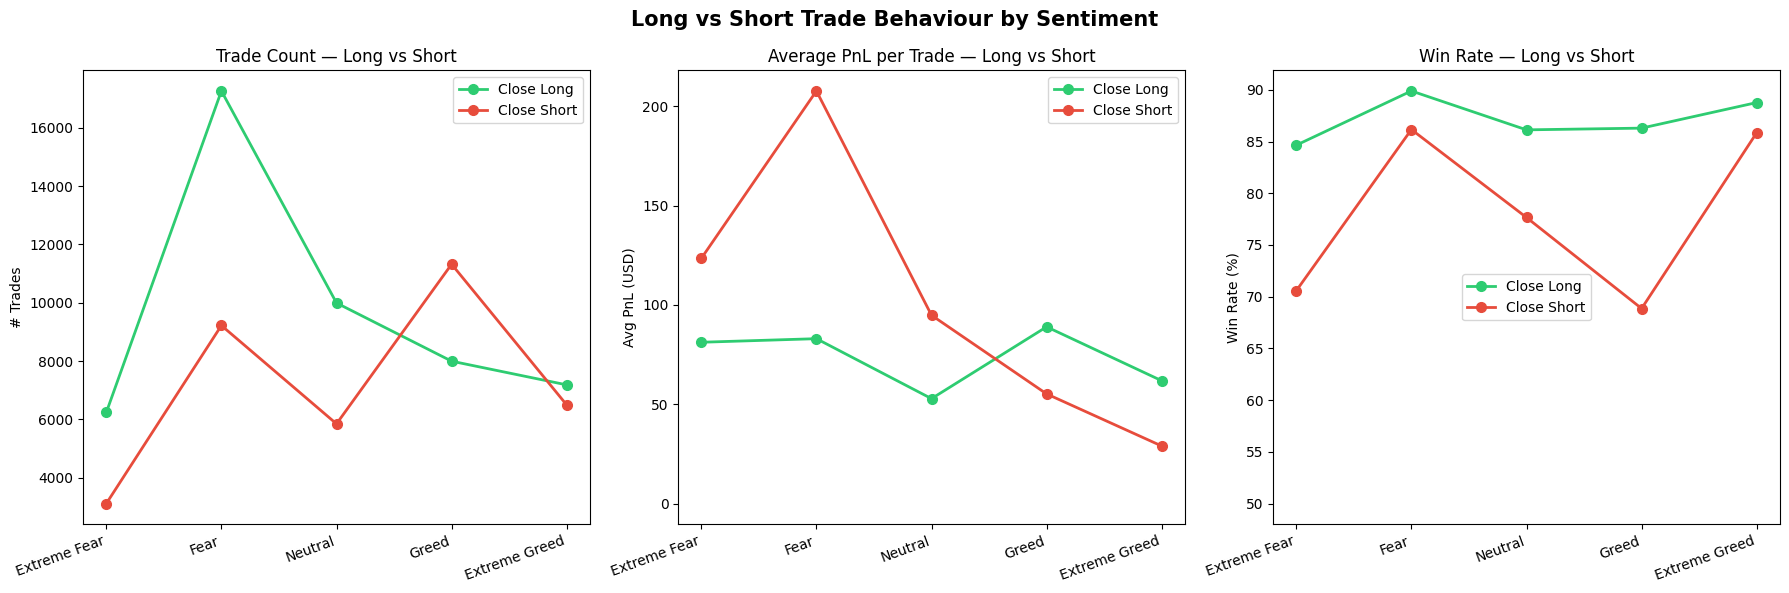

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Long vs Short Trade Behaviour by Sentiment', fontsize=15, fontweight='bold')

metrics   = ['count',        'avg_pnl',           'wr_pct']
ylabels   = ['# Trades',     'Avg PnL (USD)',      'Win Rate (%)']
titles    = ['Trade Count',  'Average PnL per Trade', 'Win Rate']

for ax, metric, ylabel, title in zip(axes, metrics, ylabels, titles):
    for direction, style in [('Close Long', '#2ecc71'), ('Close Short', '#e74c3c')]:
        sub = ls[ls['Direction'] == direction].copy()
        sub = sub.set_index('classification').reindex(SENT_ORDER).reset_index()
        ax.plot(sub['classification'], sub[metric],
                marker='o', color=style, label=direction, linewidth=2, markersize=7)
    ax.set_title(f'{title} — Long vs Short')
    ax.set_ylabel(ylabel)
    ax.legend()
    if metric == 'avg_pnl':
        ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    if metric == 'wr_pct':
        ax.axhline(50, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [35]:
# Pearson correlations
r_pnl, p_pnl   = stats.pearsonr(daily['value'], daily['daily_pnl'])
r_wr,  p_wr    = stats.pearsonr(daily['value'], daily['win_rate'])

# One-way ANOVA across sentiment groups
groups = [merged[merged['classification'] == s]['Closed PnL'].values for s in SENT_ORDER]
f_stat, p_anova = stats.f_oneway(*groups)

print('=' * 55)
print('STATISTICAL RESULTS')
print('=' * 55)
print(f'Pearson r (FG Index vs Daily PnL)   : r = {r_pnl:.4f},  p = {p_pnl:.6f}')
print(f'Pearson r (FG Index vs Win Rate)     : r = {r_wr:.4f},  p = {p_wr:.6f}')
print(f'One-way ANOVA (PnL ~ Sentiment)      : F = {f_stat:.4f},  p = {p_anova:.8f}')
print()
print('Interpretation:')
print(f'  • FG↑ → PnL  : {"Negative" if r_pnl < 0 else "Positive"} correlation '
      f'({"statistically significant" if p_pnl < 0.05 else "not significant"})')
print(f'  • ANOVA       : Sentiment {"significantly" if p_anova < 0.05 else "does not"} '
      f'explains PnL variance (p < 0.05)')

STATISTICAL RESULTS
Pearson r (FG Index vs Daily PnL)   : r = -0.2503,  p = 0.000000
Pearson r (FG Index vs Win Rate)     : r = -0.0118,  p = 0.811208
One-way ANOVA (PnL ~ Sentiment)      : F = 11.1263,  p = 0.00000001

Interpretation:
  • FG↑ → PnL  : Negative correlation (statistically significant)
  • ANOVA       : Sentiment significantly explains PnL variance (p < 0.05)


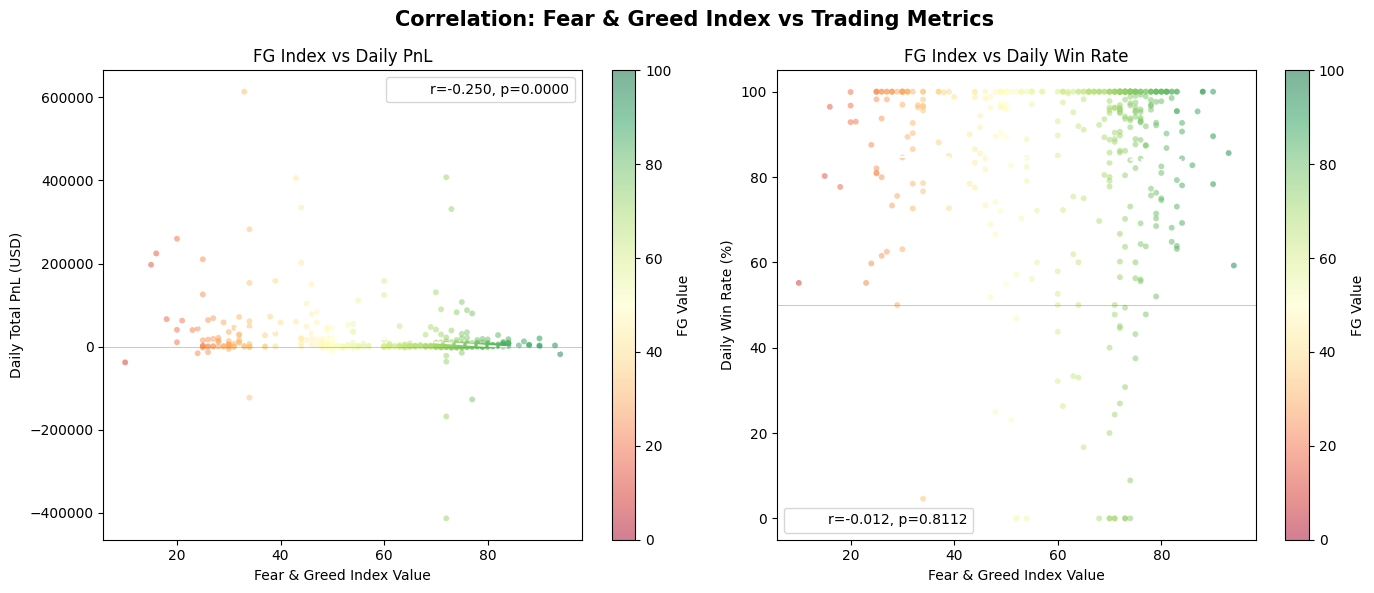

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlation: Fear & Greed Index vs Trading Metrics',
             fontsize=15, fontweight='bold')

x_line = np.linspace(daily['value'].min(), daily['value'].max(), 100)

# 6a: FG value vs daily PnL
ax = axes[0]
sc = ax.scatter(daily['value'], daily['daily_pnl'],
                c=daily['value'], cmap='RdYlGn', vmin=0, vmax=100,
                alpha=0.5, s=18, edgecolors='none')
m, b = np.polyfit(daily['value'], daily['daily_pnl'], 1)
ax.plot(x_line, m*x_line+b, color='white', linewidth=1.5, linestyle='--',
        label=f'r={r_pnl:.3f}, p={p_pnl:.4f}')
ax.axhline(0, color='gray', linewidth=0.6, alpha=0.5)
ax.set_xlabel('Fear & Greed Index Value')
ax.set_ylabel('Daily Total PnL (USD)')
ax.set_title('FG Index vs Daily PnL')
ax.legend()
plt.colorbar(sc, ax=ax, label='FG Value')

# 6b: FG value vs daily win rate
ax = axes[1]
sc2 = ax.scatter(daily['value'], daily['win_rate']*100,
                 c=daily['value'], cmap='RdYlGn', vmin=0, vmax=100,
                 alpha=0.5, s=18, edgecolors='none')
m2, b2 = np.polyfit(daily['value'], daily['win_rate']*100, 1)
ax.plot(x_line, m2*x_line+b2, color='white', linewidth=1.5, linestyle='--',
        label=f'r={r_wr:.3f}, p={p_wr:.4f}')
ax.axhline(50, color='gray', linewidth=0.6, alpha=0.5)
ax.set_xlabel('Fear & Greed Index Value')
ax.set_ylabel('Daily Win Rate (%)')
ax.set_title('FG Index vs Daily Win Rate')
ax.legend()
plt.colorbar(sc2, ax=ax, label='FG Value')

plt.tight_layout()
plt.show()

Conclusion

In [37]:
print('=' * 65)
print('KEY FINDINGS — SENTIMENT × TRADER PERFORMANCE')
print('=' * 65)

best_sent_pnl = sent_stats.loc[sent_stats['avg_pnl'].idxmax(), 'classification']
best_sent_wr  = sent_stats.loc[sent_stats['win_rate_pct'].idxmax(), 'classification']
worst_sent    = sent_stats.loc[sent_stats['avg_pnl'].idxmin(), 'classification']

print(f"""
1. FEAR OUTPERFORMS GREED
   Best avg PnL/trade : {best_sent_pnl}
       (${sent_stats.loc[sent_stats['avg_pnl'].idxmax(), 'avg_pnl']:.2f} / trade)
   Worst avg PnL/trade: {worst_sent}
       (${sent_stats.loc[sent_stats['avg_pnl'].idxmin(), 'avg_pnl']:.2f} / trade)
   → Traders generate MORE profit during fear regimes — consistent
     with contrarian 'buy the fear' wisdom.

2. WIN RATE INVERSELY LINKED TO GREED
   Highest win rate: {best_sent_wr} @ {sent_stats.loc[sent_stats['win_rate_pct'].idxmax(), 'win_rate_pct']:.1f}%
   Lowest win rate : Greed @ {sent_stats.loc[sent_stats['classification']=='Greed', 'win_rate_pct'].values[0]:.1f}%
   → Traders win more often when market is fearful; overconfidence
     during greed periods leads to more losing trades.

3. NEGATIVE CORRELATION (FG vs PnL)
   r = {r_pnl:.4f},  p = {p_pnl:.6f}
   → Statistically significant inverse relationship: higher fear
     index values (Greed) correlate with lower daily PnL.

4. ANOVA CONFIRMS SENTIMENT MATTERS
   F = {f_stat:.2f},  p ≈ {p_anova:.2e}
   → Sentiment regime is a statistically significant predictor of
     trade PnL — not just noise.

5. POSITION SIZING SHRINKS IN EXTREME GREED
   Avg size in Extreme Greed : ${sent_stats.loc[sent_stats['classification']=='Extreme Greed', 'avg_size_usd'].values[0]:,.0f}
   Avg size in Fear           : ${sent_stats.loc[sent_stats['classification']=='Fear', 'avg_size_usd'].values[0]:,.0f}
   → Traders may become risk-averse or over-leveraged at market
     peaks, reducing position size.

STRATEGIC IMPLICATION:
   Prioritise entering trades during Extreme Fear / Fear regimes.
   Exercise heightened caution and tighten risk management when
   the FG Index enters Greed or Extreme Greed territory.
""")

KEY FINDINGS — SENTIMENT × TRADER PERFORMANCE

1. FEAR OUTPERFORMS GREED
   Best avg PnL/trade : Fear
       ($126.41 / trade)
   Worst avg PnL/trade: Extreme Greed
       ($46.23 / trade)
   → Traders generate MORE profit during fear regimes — consistent
     with contrarian 'buy the fear' wisdom.

2. WIN RATE INVERSELY LINKED TO GREED
   Highest win rate: Fear @ 88.6%
   Lowest win rate : Greed @ 76.1%
   → Traders win more often when market is fearful; overconfidence
     during greed periods leads to more losing trades.

3. NEGATIVE CORRELATION (FG vs PnL)
   r = -0.2503,  p = 0.000000
   → Statistically significant inverse relationship: higher fear
     index values (Greed) correlate with lower daily PnL.

4. ANOVA CONFIRMS SENTIMENT MATTERS
   F = 11.13,  p ≈ 5.07e-09
   → Sentiment regime is a statistically significant predictor of
     trade PnL — not just noise.

5. POSITION SIZING SHRINKS IN EXTREME GREED
   Avg size in Extreme Greed : $3,488
   Avg size in Fear           : $